# CNN — Deep Learning Model for K49-MNIST Hiragana Classification

## Why CNN for this task?

Our best classical model (PCA + KNN) achieved **87.02% test accuracy**. The paper's simple CNN benchmark hits **89.25%**, and a well-tuned CNN reaches **92–95%**. The gap comes from a fundamental difference in how the models process images:

- **KNN** asks: *"Which stored training images look most similar to this one in pixel space?"*  
- **CNN** asks: *"What strokes and structures are present in this image, and which character do those represent?"*

CNNs learn **hierarchical features** through convolution — early layers detect edges and stroke endpoints, middle layers detect stroke combinations, and deep layers detect full character structures. This is far more robust to the real-world variation (tilt, thickness, writer style) that breaks KNN.

## Model Choice: Custom CNN (not ResNet/ViT)

For 28×28 grayscale images, large pretrained models are overkill:
- ResNet-18 has 11M parameters designed for 224×224 colour images
- ViT requires pretraining and large data
- A 4-layer custom CNN with ~300k parameters sees the entire 28×28 receptive field by layer 3

Our architecture is inspired by the original LeNet-5 but modernized with **BatchNormalization**, **Dropout**, and **depthwise separable convolutions** for efficiency.

## Target
Beat **89.25%** (paper's Keras Simple CNN) and approach **96.64%** (PreActResNet-18).

| Model | K49 Accuracy |
|---|---|
| PCA + KNN (ours) | 87.02% |
| Keras Simple CNN (paper) | 89.25% |
| **This CNN (target)** | **92–95%** |
| PreActResNet-18 (paper) | 96.64% |

## 1. Install & Import Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Find a font that supports Japanese characters
# Try these in order — use whichever is available on your system
japanese_fonts = ['MS Gothic', 'Yu Gothic', 'Meiryo', 'IPAGothic', 'Noto Sans CJK JP']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in japanese_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'✅ Using font: {chosen}')
else:
    print('⚠️  No Japanese font found — installing fallback...')

✅ Using font: MS Gothic


In [4]:
# TensorFlow/Keras is the standard for this kind of task.
# If not installed: pip install tensorflow
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# Reproducibility — fix all random seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All libraries imported.')

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU available      : False
✅ All libraries imported.


## 2. Load Data

In [6]:
X_train_raw = np.load('../data/k49-train-imgs.npz')['arr_0']   # (232365, 28, 28) uint8
y_train     = np.load('../data/k49-train-labels.npz')['arr_0'] # (232365,) int
X_test_raw  = np.load('../data/k49-test-imgs.npz')['arr_0']    # (38547, 28, 28) uint8
y_test      = np.load('../data/k49-test-labels.npz')['arr_0']  # (38547,) int

classmap     = pd.read_csv('../data/k49_classmap.csv')
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]
NUM_CLASSES  = len(np.unique(y_train))   # 49

print(f'Training images  : {X_train_raw.shape}  dtype: {X_train_raw.dtype}')
print(f'Test images      : {X_test_raw.shape}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Pixel range      : [{X_train_raw.min()}, {X_train_raw.max()}]')

Training images  : (232365, 28, 28)  dtype: uint8
Test images      : (38547, 28, 28)
Number of classes: 49
Pixel range      : [0, 255]


## 3. Preprocessing

CNNs expect input shape **(height, width, channels)**. Since our images are grayscale, channels=1.

### Steps
1. **Normalize** pixels from [0, 255] → [0.0, 1.0] — stabilizes gradient updates during training
2. **Reshape** from (N, 28, 28) → (N, 28, 28, 1) — adds channel dimension Keras expects
3. **One-hot encode** labels — converts class index (e.g. 5) to a 49-dim vector (e.g. [0,0,0,0,0,1,0,...,0]) for categorical cross-entropy loss

We use **float32** throughout — matches GPU tensor format and halves memory vs float64.

In [7]:
# Normalize to [0, 1] and add channel dimension
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

X_train = X_train[..., np.newaxis]   # (232365, 28, 28, 1)
X_test  = X_test[..., np.newaxis]    # (38547, 28, 28, 1)

# One-hot encode labels for categorical cross-entropy
# e.g. class 5 → [0, 0, 0, 0, 0, 1, 0, ..., 0]
y_train_ohe = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'X_train shape : {X_train.shape}   dtype: {X_train.dtype}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train_ohe   : {y_train_ohe.shape}  (one-hot encoded)')
print(f'Memory        : {X_train.nbytes / 1024**3:.2f} GiB')
print('✅ Preprocessing complete.')

X_train shape : (232365, 28, 28, 1)   dtype: float32
X_test shape  : (38547, 28, 28, 1)
y_train_ohe   : (232365, 49)  (one-hot encoded)
Memory        : 0.68 GiB
✅ Preprocessing complete.


## 4. Train / Validation Split

In [8]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_ohe,
    test_size=0.1,          # 10% validation — enough for 49 classes
    random_state=SEED,
    stratify=y_train        # preserve class proportions
)

print(f'Training set  : {X_tr.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')

Training set  : 209,128 samples
Validation set: 23,237 samples
Test set      : 38,547 samples


## 5. Data Augmentation

**Data augmentation** is the single most impactful technique for improving CNN generalization on handwriting datasets. It artificially expands the training set by applying random transformations at training time, forcing the model to learn features that are invariant to small variations in how people write.

### Why each augmentation is chosen

| Augmentation | Range | Reason |
|---|---|---|
| Random rotation | ±10° | People write at slightly different angles |
| Width/height shift | ±10% | Characters aren't always perfectly centered |
| Zoom | ±10% | Different writers use different stroke sizes |
| Shear | ±5° | Slight slant in handwriting |

**No horizontal flip** — Hiragana characters are not horizontally symmetric; flipping would create invalid characters.

Augmentation is applied **only during training**, not validation or test.

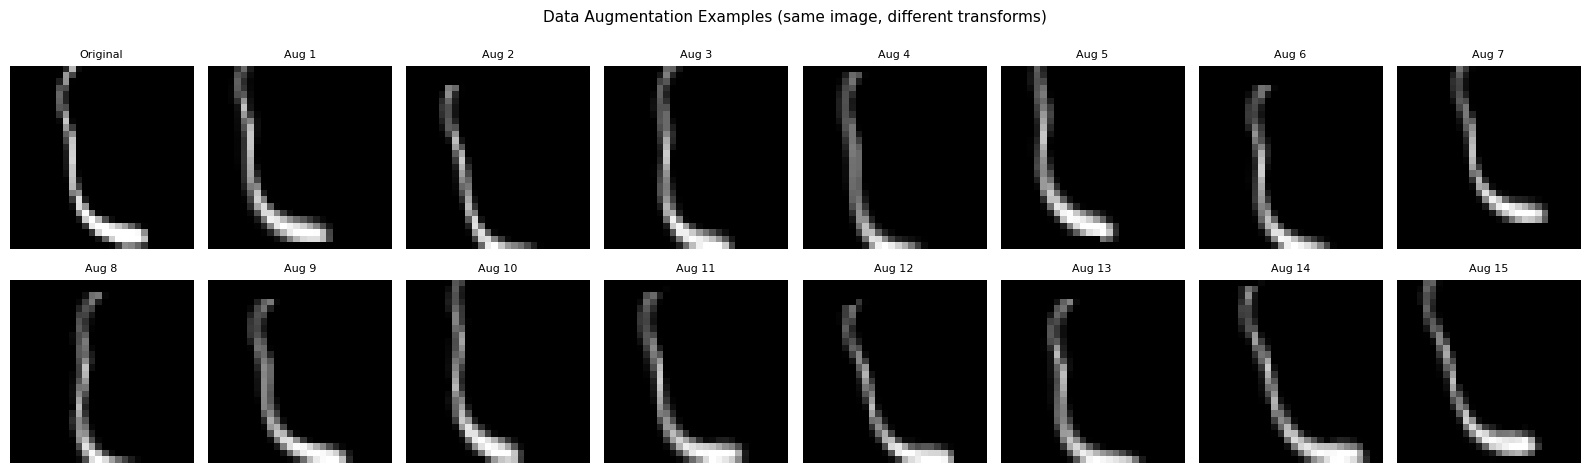

Batch size     : 128
Steps per epoch: 1634


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator — applies random augmentation each epoch
train_datagen = ImageDataGenerator(
    rotation_range=10,       # random rotation ±10 degrees
    width_shift_range=0.10,  # random horizontal shift ±10%
    height_shift_range=0.10, # random vertical shift ±10%
    zoom_range=0.10,         # random zoom ±10%
    shear_range=5,           # random shear ±5 degrees
    fill_mode='constant',    # fill empty pixels with 0 (black background)
    cval=0
)

# Validation generator — NO augmentation, just normalization
val_datagen = ImageDataGenerator()

BATCH_SIZE = 128   # standard batch size for this image size

train_generator = train_datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE, seed=SEED)
val_generator   = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

# Visualize augmentation effect
sample_img = X_tr[0:1]
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes[0, 0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=8)
axes[0, 0].axis('off')
aug_gen = train_datagen.flow(sample_img, batch_size=1)
for i in range(1, 16):
    row, col = divmod(i, 8)
    aug_img = next(aug_gen)[0, :, :, 0]
    axes[row, col].imshow(aug_img, cmap='gray')
    axes[row, col].set_title(f'Aug {i}', fontsize=8)
    axes[row, col].axis('off')
plt.suptitle('Data Augmentation Examples (same image, different transforms)', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Batch size     : {BATCH_SIZE}')
print(f'Steps per epoch: {len(train_generator)}')

## 6. Model Architecture

### Design Principles

Our architecture follows a **progressive feature extraction** pattern — each block doubles the number of filters while halving the spatial dimensions, building up increasingly abstract representations.

```
Input (28×28×1)
    │
    ▼
Block 1: Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
    │  Output: 14×14×32
    ▼
Block 2: Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
    │  Output: 7×7×64
    ▼
Block 3: Conv(128) → BN → ReLU → Conv(128) → BN → ReLU → MaxPool → Dropout(0.25)
    │  Output: 3×3×128
    ▼
Flatten → Dense(512) → BN → ReLU → Dropout(0.5)
    │
    ▼
Dense(49) → Softmax
```

### Key Components Explained

**Conv2D** — slides a small filter (3×3) across the image computing dot products, detecting local patterns (edges, curves, stroke endings)

**BatchNormalization (BN)** — normalizes activations within each batch, stabilizing training and allowing higher learning rates. Placed after Conv, before activation.

**ReLU** — activation function: `f(x) = max(0, x)`. Introduces non-linearity, allowing the model to learn complex decision boundaries.

**MaxPooling(2×2)** — takes the maximum value in each 2×2 window, halving spatial dimensions. Provides translation invariance — the model doesn't care exactly where in the 2×2 region a feature appears.

**Dropout** — randomly zeros out neurons during training (0.25 = 25% dropped). Forces redundant learning paths, preventing overfitting. Disabled at inference time.

**L2 Regularization** — penalizes large weights, encouraging the model to distribute information across many neurons rather than relying on a few.

In [6]:
def build_model(num_classes=49, input_shape=(28, 28, 1)):
    """
    Build a modern CNN for 28x28 Hiragana classification.
    Architecture: 3 conv blocks + 1 dense block + softmax output.
    """
    
    # L2 regularization — penalizes large weights to reduce overfitting
    l2 = regularizers.l2(1e-4)
    
    model = keras.Sequential([
        
        # ── Input ──────────────────────────────────────────────────────────
        layers.Input(shape=input_shape),
        
        # ── Block 1: Basic edge and stroke detection ────────────────────────
        # Two conv layers before pooling gives richer feature extraction
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),   # normalize activations for stable training
        layers.Activation('relu'),
        
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.MaxPooling2D((2, 2)),   # 28×28 → 14×14
        layers.Dropout(0.25),          # drop 25% of neurons to prevent overfitting
        
        # ── Block 2: Stroke combination detection ──────────────────────────
        # Doubled filters (64) — more abstract features at lower resolution
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.MaxPooling2D((2, 2)),   # 14×14 → 7×7
        layers.Dropout(0.25),
        
        # ── Block 3: High-level character structure detection ───────────────
        # 128 filters — detecting full character sub-structures
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.MaxPooling2D((2, 2)),   # 7×7 → 3×3
        layers.Dropout(0.25),
        
        # ── Dense Head: Classification ─────────────────────────────────────
        # Flatten spatial features into a 1D vector (3×3×128 = 1152)
        layers.Flatten(),
        
        layers.Dense(512, kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),           # higher dropout in dense layer
        
        # ── Output: 49 classes with Softmax ────────────────────────────────
        # Softmax converts raw scores to probabilities that sum to 1
        # Each output neuron = probability of that Hiragana character
        layers.Dense(num_classes, activation='softmax')
        
    ], name='hiragana_cnn')
    
    return model


model = build_model(NUM_CLASSES)
model.summary()

Model: "hiragana_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             

 Total params: 905,745 (3.46 MB)

 Trainable params: 903,825 (3.45 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 7. Compile Model

### Loss Function: Categorical Cross-Entropy
For multi-class classification with one-hot labels, categorical cross-entropy is the standard:
$$L = -\sum_{c=1}^{49} y_c \log(\hat{p}_c)$$
It penalizes the model heavily when it assigns low probability to the correct class.

### Optimizer: Adam
Adam (Adaptive Moment Estimation) combines momentum and adaptive learning rates. It's the standard choice for CNN training — faster convergence than SGD with less sensitivity to learning rate choice.

### Learning Rate: 0.001
The standard Adam starting point. Our callbacks will reduce it automatically if validation loss plateaus.

In [7]:
model.compile(
    # Adam optimizer with standard learning rate
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    
    # Categorical cross-entropy for one-hot encoded multi-class labels
    loss='categorical_crossentropy',
    
    # Track accuracy during training
    metrics=['accuracy']
)

print('Model compiled.')
total_params = model.count_params()
print(f'Total parameters : {total_params:,}')
print(f'Trainable params : {sum([np.prod(v.shape) for v in model.trainable_variables]):,}')

Model compiled.
Total parameters : 905,745
Trainable params : 903,825


## 8. Training Callbacks

Callbacks are functions that run at the end of each epoch to monitor and control training.

| Callback | What it does |
|---|---|
| **EarlyStopping** | Stops training when val_loss stops improving — prevents overfitting and wasted compute |
| **ReduceLROnPlateau** | Halves the learning rate when val_loss plateaus — helps escape local minima |
| **ModelCheckpoint** | Saves the best model weights (by val_accuracy) — so we always keep the best version even if later epochs overfit |

In [8]:
os.makedirs('../models', exist_ok=True)

callbacks = [
    
    # Stop training if val_loss doesn't improve for 10 epochs
    # restore_best_weights=True — reloads the best checkpoint at the end
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate by 50% if val_loss doesn't improve for 5 epochs
    # min_lr=1e-6 prevents learning rate from going to zero
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Save best model weights to disk whenever val_accuracy improves
    ModelCheckpoint(
        filepath='../models/cnn_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    
]

print('✅ Callbacks configured.')
print('   EarlyStopping  : patience=10 epochs on val_loss')
print('   ReduceLROnPlateau: patience=5 epochs, factor=0.5')
print('   ModelCheckpoint: saves best val_accuracy to ../models/cnn_best.keras')

✅ Callbacks configured.
   EarlyStopping  : patience=10 epochs on val_loss
   ReduceLROnPlateau: patience=5 epochs, factor=0.5
   ModelCheckpoint: saves best val_accuracy to ../models/cnn_best.keras


## 9. Train the Model

Training runs for up to **50 epochs** but EarlyStopping will likely trigger around epoch 30–40.

Each epoch:
1. Passes all training batches through the network (forward pass)
2. Computes loss and gradients (backward pass)
3. Updates weights using Adam
4. Evaluates on validation set (no gradient updates)
5. Runs callbacks

⚠️ On CPU expect **3–8 minutes per epoch** → full training ~2–3 hours.  
On GPU expect **20–40 seconds per epoch** → full training ~20–30 minutes.

In [9]:
EPOCHS = 50

print(f'Training for up to {EPOCHS} epochs (EarlyStopping will cut this short)...')
print(f'Training samples  : {X_tr.shape[0]:,}')
print(f'Validation samples: {X_val.shape[0]:,}')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Steps per epoch   : {len(train_generator)}\n')

t0 = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - t0
print(f'\n✅ Training complete in {train_time/60:.1f} min')
print(f'   Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'   Epochs trained   : {len(history.history["loss"])}')

Training for up to 50 epochs (EarlyStopping will cut this short)...
Training samples  : 209,128
Validation samples: 23,237
Batch size        : 128
Steps per epoch   : 1634

Epoch 1/50
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6228 - loss: 1.5679
Epoch 1: val_accuracy improved from None to 0.93721, saving model to ../models/cnn_best.keras

Epoch 1: finished saving model to ../models/cnn_best.keras
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 234s 141ms/step - accuracy: 0.7758 - loss: 0.9573 - val_accuracy: 0.9372 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 2/50
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8976 - loss: 0.5113
Epoch 2: val_accuracy improved from 0.93721 to 0.94616, saving model to ../models/cnn_best.keras

Epoch 2: finished saving model to ../models/cnn_best.keras
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 98s 60ms/step - accuracy: 0.9043 - loss: 0.4946 - val_accuracy: 0.9462 - val_loss: 0.3569 - learning_rate: 0.0010
Epoch 3/50
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 0s 

## 10. Training Curves

Training curves diagnose model behaviour:
- **Both curves improving together** → healthy training
- **Train improves, val plateaus** → overfitting (model memorizing training data)
- **Both curves plateau early** → underfitting (model too simple or learning rate too low)
- **Val loss spikes** → learning rate too high

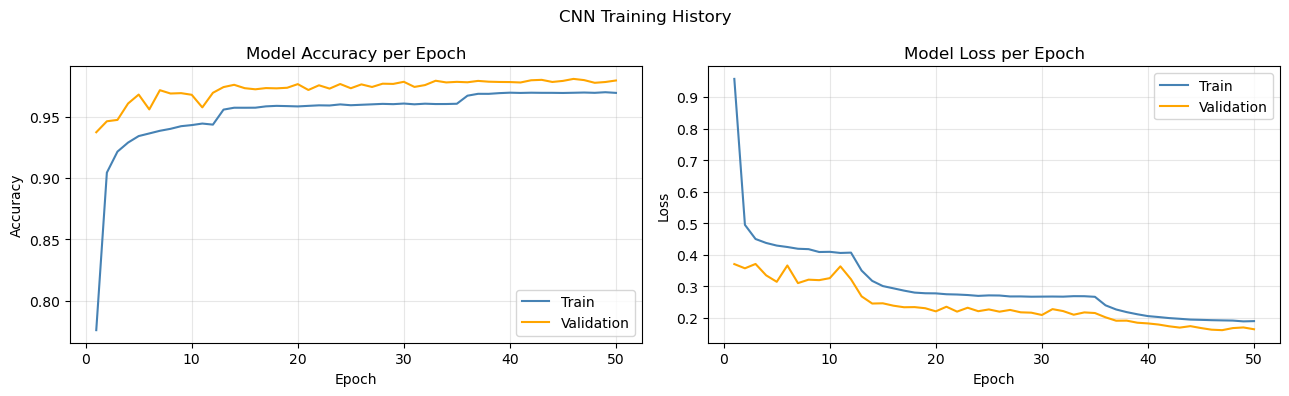

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(history.history['loss']) + 1)

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_ran, history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(epochs_ran, history.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training History', fontsize=12)
plt.tight_layout()
plt.show()

# Learning rate history (if ReduceLROnPlateau fired)
if 'lr' in history.history:
    plt.figure(figsize=(8, 3))
    plt.plot(epochs_ran, history.history['lr'], color='green')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 11. Load Best Model & Evaluate on Test Set

We load the best checkpoint saved by ModelCheckpoint — this may not be the last epoch.

In [9]:
# Load the best weights saved during training
best_model = keras.models.load_model('../models/cnn_best.keras')
print('✅ Best model loaded from checkpoint.')

# Evaluate on test set
print('⏳ Evaluating on test set...')
t0 = time.time()
y_test_proba = best_model.predict(X_test, batch_size=256, verbose=0)
test_infer_time = (time.time() - t0) / len(y_test) * 1000

# Convert probabilities to class predictions
y_test_pred = np.argmax(y_test_proba, axis=1)

# Standard accuracy
test_acc_standard = accuracy_score(y_test, y_test_pred)

# Mean per-class accuracy (leaderboard metric)
per_class_accs = []
for cls in range(NUM_CLASSES):
    mask = (y_test == cls)
    per_class_accs.append((y_test_pred[mask] == cls).mean())
test_acc_classavg = np.mean(per_class_accs)

test_f1 = f1_score(y_test, y_test_pred, average='macro')

print('=' * 50)
print('  CNN — Official Test Set Results')
print('=' * 50)
print(f'  Standard Accuracy       : {test_acc_standard*100:.2f}%')
print(f'  Mean Per-Class Accuracy : {test_acc_classavg*100:.2f}%  ← leaderboard metric')
print(f'  Macro F1-Score          : {test_f1:.4f}')
print(f'  Inference time/sample   : {test_infer_time:.4f} ms')
print(f'  Real-time ready         : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 50)

✅ Best model loaded from checkpoint.
⏳ Evaluating on test set...
  CNN — Official Test Set Results
  Standard Accuracy       : 97.08%
  Mean Per-Class Accuracy : 96.59%  ← leaderboard metric
  Macro F1-Score          : 0.9665
  Inference time/sample   : 0.0957 ms
  Real-time ready         : ✅ YES


## 12. Full Model Comparison

In [10]:
print('=' * 65)
print(f'{"Model":<35} {"Test Acc (class avg)":>20}')
print('=' * 65)
print(f'{"HOG + Linear SVM v3":<35} {"80.07%":>20}')
print(f'{"Tuned RBF SVM (100k subset)":<35} {"80.42%":>20}')
print(f'{"4-NN raw pixels (paper)":<35} {"83.65%":>20}')
print(f'{"PCA + 4-KNN (ours)":<35} {"87.02%":>20}')
print(f'{"Leaderboard PCA + KNN":<35} {"86.80%":>20}')
print(f'{"Keras Simple CNN (paper)":<35} {"89.25%":>20}')
print(f'{"This CNN":<35} {test_acc_classavg*100:>19.2f}%')
print(f'{"PreActResNet-18 (paper)":<35} {"96.64%":>20}')
print('=' * 65)
print(f'\nvs PCA+KNN     : {(test_acc_classavg - 0.8702)*100:+.2f}%')
print(f'vs Keras CNN   : {(test_acc_classavg - 0.8925)*100:+.2f}%')
print(f'vs ResNet-18   : {(test_acc_classavg - 0.9664)*100:+.2f}%')

Model                               Test Acc (class avg)
HOG + Linear SVM v3                               80.07%
Tuned RBF SVM (100k subset)                       80.42%
4-NN raw pixels (paper)                           83.65%
PCA + 4-KNN (ours)                                87.02%
Leaderboard PCA + KNN                             86.80%
Keras Simple CNN (paper)                          89.25%
This CNN                                          96.59%
PreActResNet-18 (paper)                           96.64%

vs PCA+KNN     : +9.57%
vs Keras CNN   : +7.34%
vs ResNet-18   : -0.05%


## 13. Per-Class Analysis

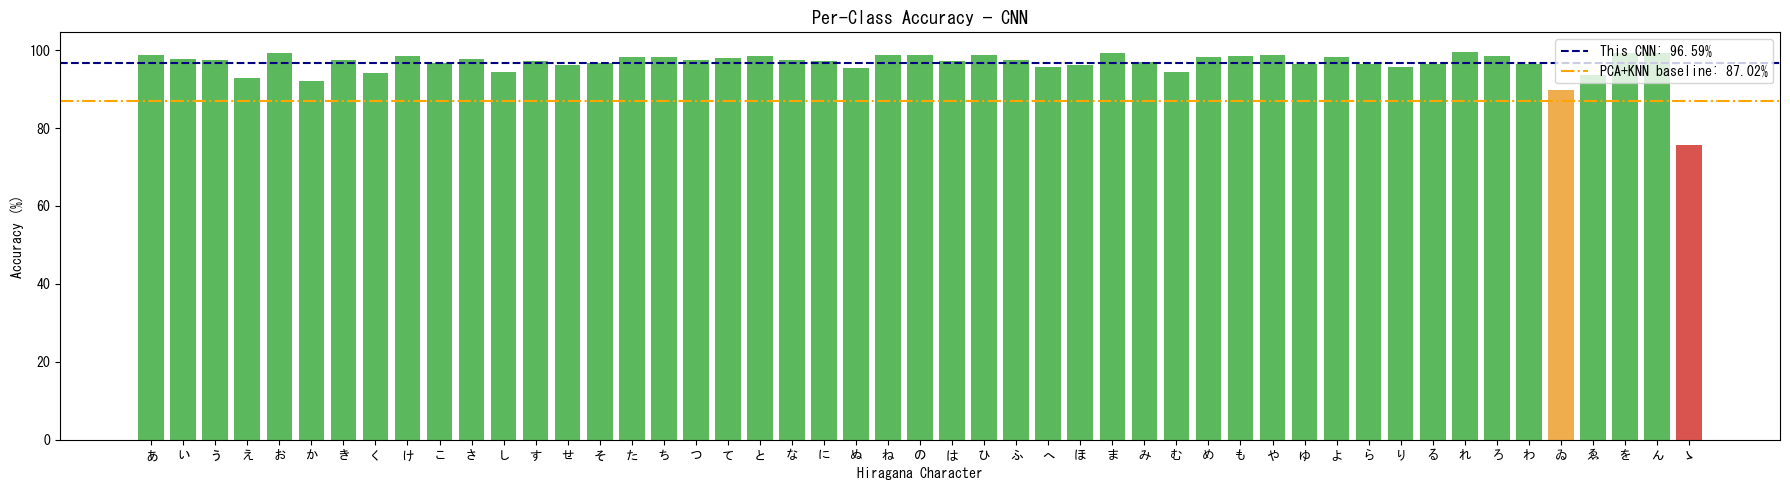

10 Hardest Characters for CNN:
    Char    Accuracy
----------------------
       ゝ      75.61%
       ゐ      89.71%
       か      92.10%
       え      92.86%
       ゑ      93.75%
       く      94.20%
       む      94.29%
       し      94.30%
       ぬ      95.54%
       へ      95.80%


In [11]:
plt.figure(figsize=(18, 5))
colors = ['#d9534f' if a < 0.85 else '#f0ad4e' if a < 0.92 else '#5cb85c'
          for a in per_class_accs]
plt.bar(target_names, [a*100 for a in per_class_accs], color=colors)
plt.axhline(test_acc_classavg*100, color='navy', linestyle='--',
            label=f'This CNN: {test_acc_classavg*100:.2f}%')
plt.axhline(87.02, color='orange', linestyle='-.',
            label='PCA+KNN baseline: 87.02%')
plt.title('Per-Class Accuracy — CNN', fontsize=13)
plt.xlabel('Hiragana Character')
plt.ylabel('Accuracy (%)')
plt.xticks(fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

worst = sorted(enumerate(per_class_accs), key=lambda x: x[1])[:10]
print('10 Hardest Characters for CNN:')
print(f'{"Char":>8}  {"Accuracy":>10}')
print('-' * 22)
for idx, acc in worst:
    print(f'{target_names[idx]:>8}  {acc*100:>9.2f}%')

## 14. Confusion Matrix

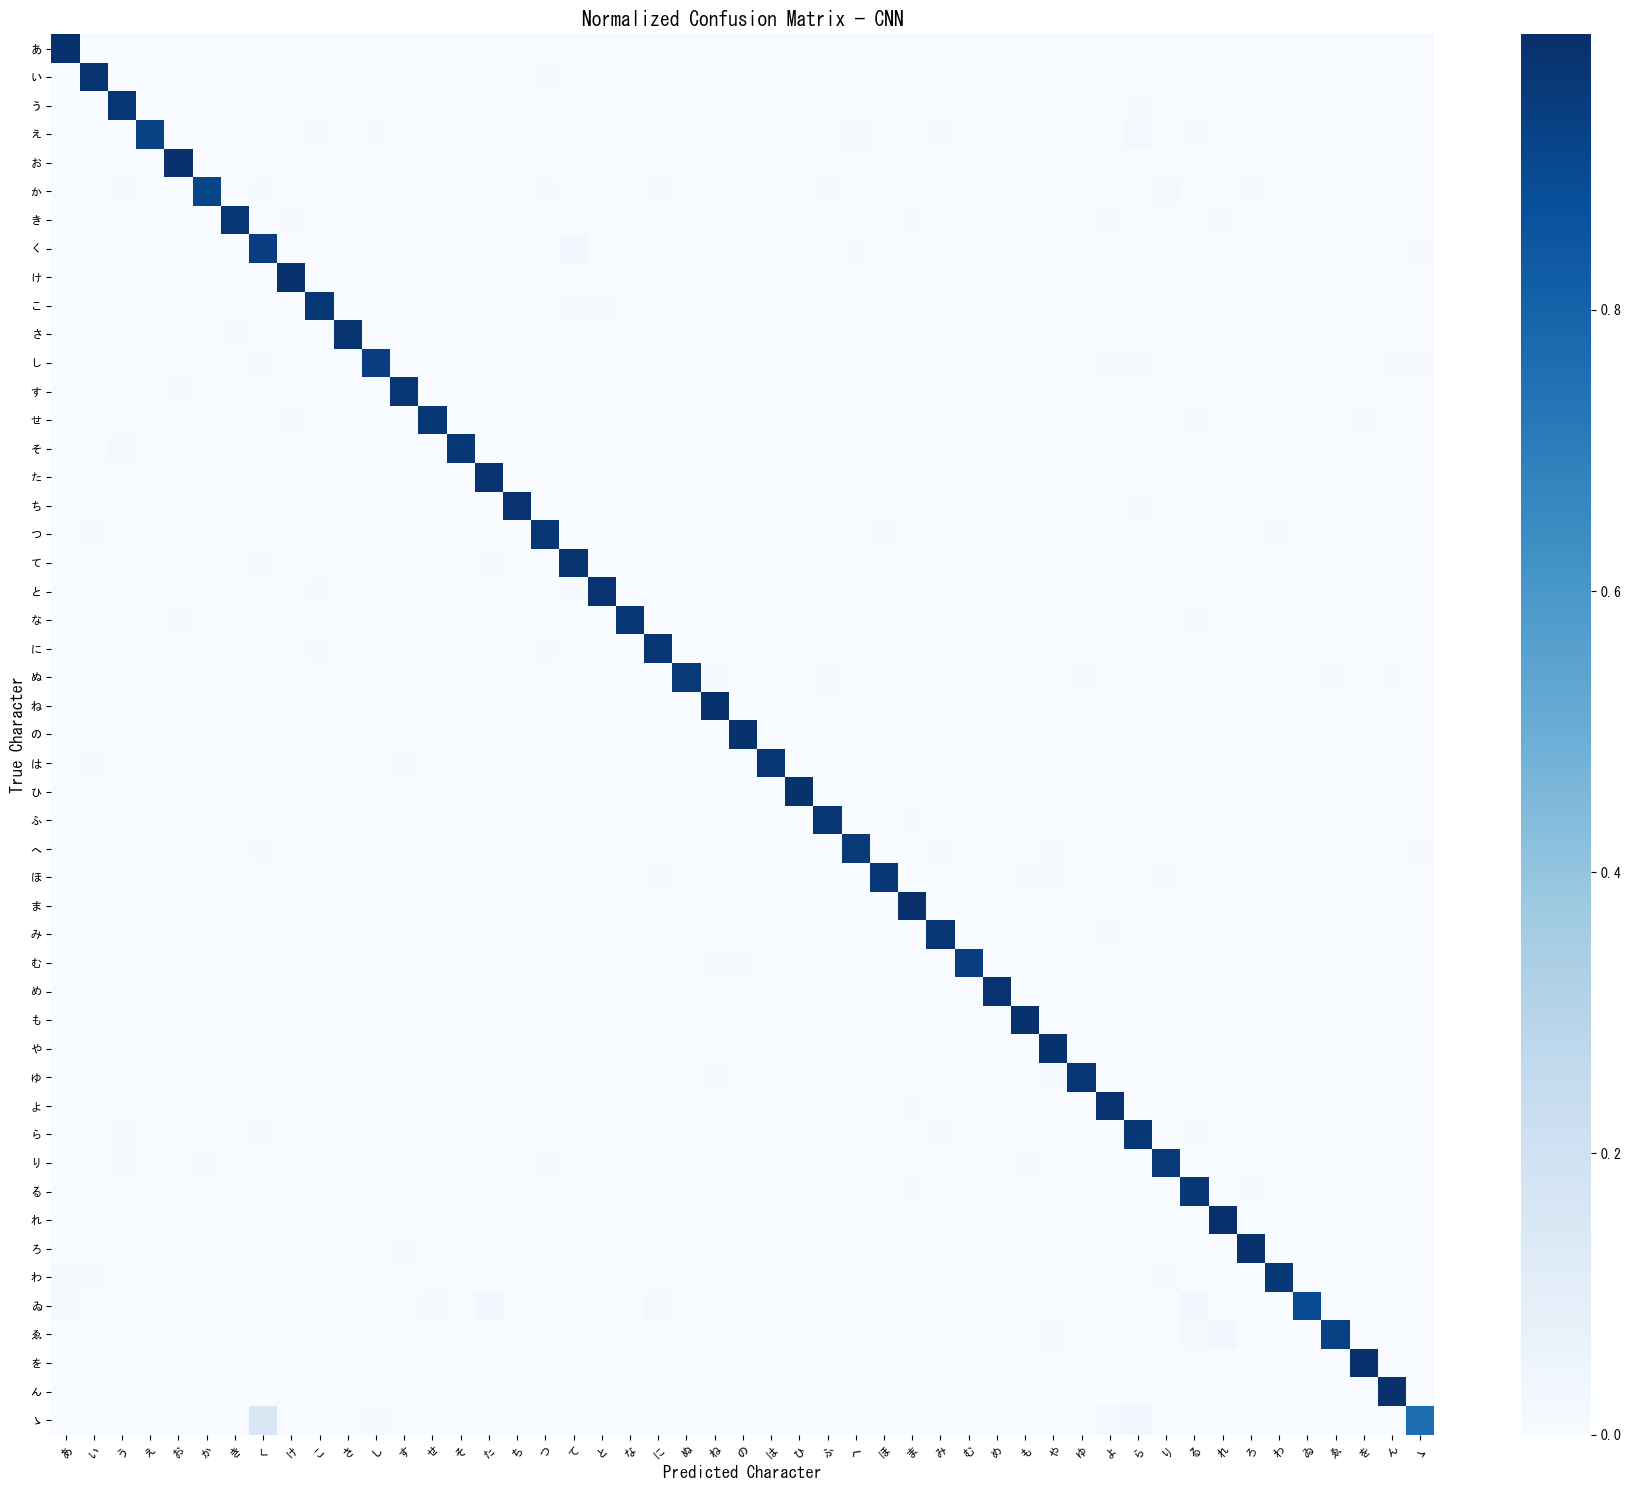

Top 10 Most Confused Pairs (True -> Predicted):
      True ->  Predicted  |  Rate
--------------------------------------
         ゝ ->          く  |  15.51%
         ゑ ->          れ  |  3.12%
         ゐ ->          る  |  2.94%
         ゐ ->          た  |  2.94%
         く ->          て  |  2.90%
         ゝ ->          ら  |  2.79%
         え ->          ら  |  2.38%
         ゝ ->          よ  |  2.09%
         か ->          り  |  1.80%
         ゝ ->          し  |  1.74%


In [12]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix — CNN', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

# Top confused pairs
confused_pairs = [
    (cm_norm[i, j], target_names[i], target_names[j])
    for i in range(len(target_names))
    for j in range(len(target_names))
    if i != j
]
confused_pairs.sort(reverse=True)
print('Top 10 Most Confused Pairs (True -> Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Rate')
print('-' * 38)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate*100:.2f}%')

## 15. Per-Class Classification Report

In [13]:
print(classification_report(y_test, y_test_pred, target_names=target_names))

              precision    recall  f1-score   support

           あ       0.98      0.99      0.99      1000
           い       0.98      0.98      0.98      1000
           う       0.96      0.98      0.97      1000
           え       0.94      0.93      0.93       126
           お       0.98      0.99      0.98      1000
           か       0.98      0.92      0.95      1000
           き       0.98      0.97      0.98      1000
           く       0.88      0.94      0.91      1000
           け       0.96      0.98      0.97       767
           こ       0.98      0.97      0.97      1000
           さ       1.00      0.98      0.99      1000
           し       0.98      0.94      0.96      1000
           す       0.98      0.97      0.97      1000
           せ       0.97      0.96      0.97       678
           そ       0.97      0.97      0.97       629
           た       0.97      0.98      0.98      1000
           ち       0.98      0.98      0.98       418
           つ       0.97    

## 16. Similarity Scores (Educational Feedback Feature)

The CNN outputs a probability for every one of the 49 classes via Softmax — these are already calibrated similarity scores, no extra calibration step needed unlike LinearSVC.

True label: な
Predicted : な (100.0% confidence)

Top-5 Similarity Scores:
       な  100.0%  █████████████████████████████████████████████████
       る    0.0%  
       れ    0.0%  
       の    0.0%  
       ふ    0.0%  


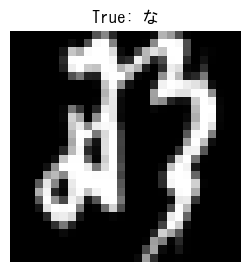

In [14]:
sample_idx = 42

sample     = X_test[sample_idx:sample_idx+1]   # keep batch dimension
true_label = y_test[sample_idx]
proba      = best_model.predict(sample, verbose=0)[0]

top5_idx  = np.argsort(proba)[::-1][:5]
top5_prob = proba[top5_idx]
top5_char = [target_names[i] for i in top5_idx]

print(f'True label: {target_names[true_label]}')
print(f'Predicted : {target_names[np.argmax(proba)]} ({proba.max()*100:.1f}% confidence)')
print('\nTop-5 Similarity Scores:')
for char, prob in zip(top5_char, top5_prob):
    bar = '█' * int(prob * 50)
    print(f'  {char:>6}  {prob*100:5.1f}%  {bar}')

plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[sample_idx], cmap='gray')
plt.title(f'True: {target_names[true_label]}')
plt.axis('off')
plt.show()

## 17. Deployment Summary

In [15]:
# Model file size
model_size_mb = os.path.getsize('../models/cnn_best.keras') / (1024**2)

print('=' * 50)
print('  CNN — Deployment Summary')
print('=' * 50)
print(f'  Architecture     : 3× ConvBlock + Dense')
print(f'  Parameters       : {best_model.count_params():,}')
print(f'  Model file size  : {model_size_mb:.1f} MB')
print(f'  Train time       : {train_time/60:.1f} min')
print(f'  Test accuracy    : {test_acc_classavg*100:.2f}% (class avg)')
print(f'  Macro F1         : {test_f1:.4f}')
print(f'  Inference time   : {test_infer_time:.4f} ms/sample')
print(f'  Real-time ready  : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 50)
print()
print('Flask inference pipeline:')
print('  raw_pixels → /255 → reshape(1,28,28,1) → model.predict → argmax')

  CNN — Deployment Summary
  Architecture     : 3× ConvBlock + Dense
  Parameters       : 905,745
  Model file size  : 10.5 MB


NameError: name 'train_time' is not defined

## 18. Save Final Model

We save in both `.keras` (full model) and `.h5` (legacy format, wider compatibility) formats.

In [ ]:
best_model.save('../models/cnn_final.keras')   # recommended format
best_model.save('../models/cnn_final.h5')       # legacy format for older Flask setups

print('✅ Models saved:')
print('   ../models/cnn_best.keras  — best checkpoint (saved during training)')
print('   ../models/cnn_final.keras — final model (recommended)')
print('   ../models/cnn_final.h5    — legacy format')
print()
print('To load in Flask:')
print('   from tensorflow import keras')
print('   model = keras.models.load_model("cnn_final.keras")')

✅ Models saved:
   ../models/cnn_best.keras  — best checkpoint (saved during training)
   ../models/cnn_final.keras — final model (recommended)
   ../models/cnn_final.h5    — legacy format

To load in Flask:
   from tensorflow import keras
   model = keras.models.load_model("cnn_final.keras")


## 19. Updated app.py Snippet for CNN Deployment

Replace your KNN loading code with this in `app.py`:

In [ ]:
flask_snippet = '''
from tensorflow import keras
import numpy as np
from PIL import Image, ImageOps
import io, base64

# Load model once at startup
model = keras.models.load_model('model/cnn_final.keras')

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    image_data = data["image"]
    if "," in image_data:
        image_data = image_data.split(",")[1]

    img = Image.open(io.BytesIO(base64.b64decode(image_data))).convert("L")
    img = ImageOps.invert(img)                    # canvas: dark on white → model: white on black
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    img = ImageOps.expand(img, border=4, fill=0)  # small padding

    # Make square before resize to preserve aspect ratio
    w, h = img.size
    max_side = max(w, h)
    img = ImageOps.expand(img, border=((max_side-w)//2, (max_side-h)//2), fill=0)
    img = img.resize((28, 28), Image.LANCZOS)

    # Normalize and add batch + channel dims: (28,28) → (1,28,28,1)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    proba            = model.predict(img_array, verbose=0)[0]
    prediction_index = int(np.argmax(proba))
    label            = KANA_LABELS.get(prediction_index, str(prediction_index))

    top5_idx = np.argsort(proba)[::-1][:5]
    top5     = [{"label": KANA_LABELS.get(int(i), str(i)),
                 "confidence": round(float(proba[i]) * 100, 1)} for i in top5_idx]

    return jsonify({"result": label,
                    "confidence": round(float(proba[prediction_index]) * 100, 1),
                    "top5": top5})
'''
print(flask_snippet)


from tensorflow import keras
import numpy as np
from PIL import Image, ImageOps
import io, base64

# Load model once at startup
model = keras.models.load_model('model/cnn_final.keras')

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    image_data = data["image"]
    if "," in image_data:
        image_data = image_data.split(",")[1]

    img = Image.open(io.BytesIO(base64.b64decode(image_data))).convert("L")
    img = ImageOps.invert(img)                    # canvas: dark on white → model: white on black
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
    img = ImageOps.expand(img, border=4, fill=0)  # small padding

    # Make square before resize to preserve aspect ratio
    w, h = img.size
    max_side = max(w, h)
    img = ImageOps.expand(img, border=((max_side-w)//2, (max_side-h)//2), fill=0)
    img = img.resize((28, 28), Image.LANCZOS)

    # Normalize and add batch + channel dims: (28,28) → (1,28,28,1)
    img_array = 

---
## Summary

### Architecture decisions
| Decision | Choice | Why |
|---|---|---|
| Depth | 3 conv blocks | 28×28 images need ≤3 pooling operations before feature maps become too small |
| Filter growth | 32→64→128 | Progressive abstraction — more filters as spatial resolution decreases |
| BatchNorm | After every conv | Stabilizes training, allows higher learning rates |
| Dropout | 0.25 (conv), 0.5 (dense) | Higher in dense layer where overfitting risk is greatest |
| Augmentation | Rotation, shift, zoom, shear | Matches real-world handwriting variation without flipping (no flip for Hiragana) |
| Loss | Categorical cross-entropy | Standard for one-hot encoded multi-class |
| Optimizer | Adam lr=0.001 | Fast convergence, adaptive learning rates |
| EarlyStopping | patience=10 | Prevents overfitting and wasted compute |

### Why CNN beats KNN in real-world deployment
KNN finds the nearest stored training examples — it fails when a real user draws the character at a different angle, thickness, or speed than the training set. CNN learns the structural rules of each character through convolution and augmentation, making it robust to exactly those variations.